In [1]:
import numpy as np

## Soluzione di sistemi diagonali in numpy

$$
A = \begin{pmatrix}
d_1 & \\
    &d_2 &\\
		&    &\ddots &\\
		&    &       & d_n
\end{pmatrix},\quad \det(A) = d_1\cdot d_2\cdot ... \cdot d_n
$$

Sistema in forma esplicita:

$$d_ix_i = b_i,\; i=1,\dots,n \quad\Rightarrow\quad x_i = \frac{b_i}{d_i},\; i=1,\dots,n$$

Costo computazionale: $n$ quozienti $\Rightarrow \mathcal{O}(n)$.

*   Le matrici diagonali sono memorizzate su vettori;
*   La soluzione del sistema si ottiene dividendo elemento per elemento i vettori contenenti la diagonale della matrice e il termine noto.

**Esempio**

Risolvere il sistema diagonale $Ax=b$ dove:

$$
A = \begin{pmatrix}
1 & \\
    &2 &\\
		&    &\ddots &\\
		&    &       & n
\end{pmatrix},\quad b = \begin{pmatrix} n\\ n-1\\ \vdots\\ 1
\end{pmatrix}

$$

per $n=6$.



In [2]:
n = 6                   # Dimensione della matrice quadrata
d = np.arange(1,n+1)    # Vettore dei coefficienti della diagonale principale di A
b = np.arange(n,0,-1)   # Vettore dei termini noti
x = b / d               # Risolvendo le incognite: incognita = termine noto / coefficiente
print(x)

[6.         2.5        1.33333333 0.75       0.4        0.16666667]


Spiegazione:

1. Si definisce la dimensione della matrice;
2. Si costruisce il vettore `d` contenente i coefficienti della diagonale principale di $A$: $d = [1,2,3,4,5,6]$;
3. Si costruisce il vettore `b` dei termini noti del sistema: $b = [6,5,4,3,2,1]$;
4. Poiché la matrice è diagonale, ogni equazione del sistema è:
   $$d_i x_i = b_i$$
   quindi ogni incognita si ottiene con:
   $$x_i = \frac{b_i}{d_i}$$
5. In NumPy la soluzione si calcola con una *divisione elemento per elemento*;
6. Il vettore `x` contiene la soluzione del sistema.

## Soluzione di sistemi triangolari

Caso triangolare inferiore:

$$R=\left(\begin{array}{cccc}
r_{11} &       &        & \\
r_{21} & r_{22}&        & \\
\vdots &       & \ddots & \\
r_{n1} &r_{n2} & \dots  & r_{nn}
\end{array}\right)$$

Algoritmo di sostituzione in avanti:

$${\begin{array}{l}
    \text{for } j=1,\dots,n \\
    \begin{array}{rl}
    \left\lfloor \right.& \begin{array}{l}
            {\color{lightblue}x_j} = \displaystyle\frac{b_j- \sum_{i=1}^{j-1}r_{ji}{\color{lightblue}x_i}}{r_{jj}}
            \end{array}
    \end{array}
\end{array}}$$

Complessità computazionale: $\mathcal{O}(n^2/2)$ somme e $\mathcal{O}(n^2/2)$ prodotti.

**Generazione di un sistema test**

Per testare la correttezza degli algoritmi, spesso si costruiscono dei problemi test artificiali di cui si conosce la soluzione, con la quale vengono confrontati i risultati ottenuti dall'algoritmo.

Per creare un sistema lineare di test, si può procedere nel seguente modo

*   Scegliere la matrice dei coefficienti $A$ (nonsingolare);
*   Scegliere un vettore-soluzione $s$;
*   Calcolare il vettore $b=As$.

In questo modo il sistema $Ax=b$ avrà come unica soluzione il vettore $s$.

> Le funzioni per la soluzione di sistemi con struttura speciale si trovano nella libreria **SciPy**, che gestisce gli `nd.array` di **Numpy**. In particolare, per i sistemi triangolari abbiamo `solve_triangular` che implementa entrambi i metodi di sostituzione, in avanti e all'indietro (*default*).

In [3]:
# Creazione di un sistema lineare di test con matrice triangolare inferiore
n = 5                               # Dimensione della matrice (10 x 10)

A = np.tril(                        # Mantiene solo la parte triangolare inferiore della matrice
    np.abs(                         # Rende tutti i valori positivi
        np.random.randn(n, n)       # Genera una matrice n x n con valori casuali (distribuzione normale)
    )
)
print('Matrice A:', A, sep='\n')    # Stampa la matrice

# Verifica che la matrice sia non singolare (quindi invertibile)
d = np.diag(A).prod()               # Per una matrice triangolare: det(A) = prodotto degli elementi sulla diagonale
print('det(A) =', d)                # Stampa il determinante
print('Invertibile? (det(A) != 0.0):', d != 0)  # La matrice è invertibile se il determinante è diverso da 0

# Definizione di una soluzione nota e costruzione del termine noto
s = np.ones(n)                      # Vettore soluzione scelto: tutti 1
b = A @ s                           # Calcolo del termine noto: b = A·s

Matrice A:
[[0.52737629 0.         0.         0.         0.        ]
 [1.14640946 1.68601228 0.         0.         0.        ]
 [0.16065224 0.01281223 2.0432726  0.         0.        ]
 [0.75782845 1.90545799 1.49409451 1.69190826 0.        ]
 [0.06808452 1.6573291  0.53909137 0.25965233 1.85755765]]
det(A) = 5.709877030818083
Invertibile? (det(A) != 0.0): True


In [4]:
# Funzione per generare una matrice randomica traingolare inferiore/superiore

def rand_tri_system(n: int, lower: bool = True):
    tri_func = np.tril if lower else np.triu  # Scegli funzione per triangolare
    generate_matrix = lambda: tri_func(np.abs(np.random.randn(n, n)))  # Matrice casuale positiva

    A = generate_matrix()            # Prima matrice
    while np.prod(np.diag(A)) == 0:  # Rigenera se diagonale contiene zeri
        A = generate_matrix()

    s = np.ones(n)  # Vettore soluzione noto
    b = A @ s       # Termini noti

    return A, b

In [5]:
# Algoritmo di sostituzione in avanti home-made

def ltrisol(A, b):
  x = np.zeros(b.shape)       # Inizializza il vettore soluzione x con zeri (stessa dimensione di b)
  for j in range(b.size):     # Scorre le equazioni del sistema dalla prima all'ultima
    # Calcola x_j usando la formula della sostituzione in avanti
    x[j] = (b[j] - (A[j,:j] * x[:j]).sum()) / A[j, j]
  return x                    # Restituisce il vettore soluzione

Parametri della funzione `ltrisol(A, b)`:

- $A \to$ matrice quadrata **triangolare inferiore** di dimensione $n \times n$;
- $b \to$ vettore dei **termini noti** del sistema lineare $Ax = b$;
- $x \to$ vettore **soluzione** del sistema;

Variabili della funzione:

- $x_j \to$ $j$-esima incognita da calcolare;
- $b_j \to$ $j$-esimo termine noto del vettore $b$;
- $A[j,j] \to$ elemento sulla **diagonale principale** della riga $j$;
- $A[j,:j] \to$ nella riga $j$ della matrice $A$, tutti gli elementi **dalla colonna $0$ alla colonna $j-1$**;
- $x[:j] \to$ nel vettore soluzione $x$, le **prime $j$ componenti già calcolate** ($x_0, \dots, x_{j-1}$).

Poiché $A$ è triangolare inferiore, ogni incognita si calcola con:

$$
x_j = \frac{b_j - \sum_{i=0}^{j-1} A_{j,i} x_i}{A_{j,j}}
$$

Le incognite vengono quindi determinate **in ordine**, dalla prima all'ultima, utilizzando i valori già calcolati (sostituzione in avanti).

In [6]:
# Soluzione algoritmo personalizzato
n = 10
A, b = rand_tri_system(n)
x = ltrisol(A, b)
err = np.linalg.norm(x - np.ones(n))

print('=== Sostituzione in Avanti | Algoritmo home-made ===')
print('x =', x)
print('err =', err)

=== Sostituzione in Avanti | Algoritmo home-made ===
x = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
err = 1.7699267245687042e-14


In [7]:
from scipy.linalg import solve_triangular

# Soluzione con scipy
n = 10
A, b = rand_tri_system(n)
x1 = solve_triangular(A, b, lower=True)
err1 = np.linalg.norm(x1 - np.ones(n))

print('=== Sostituzione in Avanti | Algoritmo scipy ===')
print('x =', x1)
print('err =', err1)

=== Sostituzione in Avanti | Algoritmo scipy ===
x = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
err = 2.1366818269106342e-14


In [8]:
import timeit
from scipy.linalg import solve_triangular

# Calcolare il tempo di esecuzione dei due algoritmi
A, b = rand_tri_system(1000)

t_scipy = timeit.timeit(lambda: solve_triangular(A, b, lower=True), number=10)
t_ours = timeit.timeit(lambda: ltrisol(A, b), number=10)

print('Tempo nostro algoritmo :', t_ours)
print('Tempo algoritmo SciPy  :', t_scipy)

Tempo nostro algoritmo : 0.06640648100000135
Tempo algoritmo SciPy  : 0.0318823650000013


Caso triangolare superiore:

$$R=\left(\begin{array}{cccc}
r_{11}  & r_{12} & \dots  & r_{1n} \\
        & r_{22} & \dots  & r_{2n} \\
        &        & \ddots & \vdots \\
        &        &        & r_{nn}
\end{array}\right)$$

Algoritmo di sostituzione all'indietro:

$${\begin{array}{l}
\text{for } j=n,\dots,1\\
\begin{array}{rl}
\left\lfloor \right.& \begin{array}{l}
           {\color{lightblue}x_j} = \displaystyle\frac{b_j- \sum_{i=j+1}^{n}r_{ji}{\color{lightblue}x_i}}{r_{jj}}
          \end{array}
\end{array}
\end{array}}$$

Complessità computazionale: $\mathcal{O}(n^2/2)$ somme e $\mathcal{O}(n^2/2)$ prodotti.

In [9]:
# Algoritmo di sostituzione all'indietro home-made

def utrisol(A, b):
    x = np.zeros(b.shape)
    for j in reversed(range(b.size)):  # Ciclo invertito
        # Calcola x_j usando la formula della sostituzione all'indietro
        x[j] = (b[j] - (A[j,j+1:] * x[j+1:]).sum()) / A[j,j]
    return x

In [10]:
# Soluzione algoritmo personalizzato
n = 10
xu = utrisol(*rand_tri_system(n, lower=False))
erru = np.linalg.norm(x1 - np.ones(n))

print('=== Sostituzione all\'indietro | Algoritmo home-made ===')
print('x =', xu)
print('err =', erru)

=== Sostituzione all'indietro | Algoritmo home-made ===
x = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
err = 2.1366818269106342e-14


## Esercizio | Sistema mal condizionato

Consideriamo la seguente matrice $n\times n$ e il vettore $b$:

$$A=\begin{pmatrix}
1& & & & & 2^0\\
 &1& & & & 2^1\\
 & &1& & & 2^2\\
 & & & \ddots & & \vdots\\
 & & & &1& 2^{n-2}\\
 & & & & & 2^{n-1}
\end{pmatrix},\quad b = \begin{pmatrix}
  1+2^0\\
  1+2^1\\
  1+2^2\\
  \vdots\\
  1+2^{n-2}\\
  2^{n-1}
\end{pmatrix}$$
L'unica soluzione del sistema è il vettore con tutte le componenti uguali a 1.

In [11]:
import numpy as np
from scipy.linalg import solve_triangular

n = 100

# --- Matrice dei coefficienti ---
A = np.eye(n)                  # Matrice identità n x n
A[:, -1] = 2. ** np.arange(n)  # Sostituiamo l'ultima colonna con 2^0, 2^1, ..., 2^(n-1)

# --- Vettore dei termini noti ---
b = 2. ** np.arange(n)         # b = [2^0, 2^1, ..., 2^(n-1)]
b[:n-1] += 1                   # Per le prime n-1 componenti aggiungiamo 1

# --- Risoluzione del sistema triangolare ---
x = solve_triangular(A, b)     # Risolve Ax = b (matrice triangolare)

# --- Controllo della soluzione ---
err = np.linalg.norm(x - np.ones(n))  # Norma dell'errore rispetto alla soluzione esatta (vettore di 1)
cond = np.linalg.cond(A)              # Numero di condizionamento della matrice

print("Errore rispetto alla soluzione:", err)
print("Numero di condizionamento:", cond)

Errore rispetto alla soluzione: 6.782329983125268
Numero di condizionamento: 8.451004001521529e+29


### Malcondizionamento del sistema lineare

Il sistema lineare affrontato è **mal condizionato** a causa della grande differenza di scala tra gli elementi della matrice. Analizziamo il motivo passo passo.

1. Ultima equazione (calcolo corretto):
    $$
    2^{n-1} x_n = 2^{n-1} \quad \Rightarrow \quad x_n = \frac{2^{n-1}}{2^{n-1}} = 1
    $$

2. Penultima equazione (errore di rappresentazione floating point):
    $$
    x_{n-1} + 2^{n-2} \underbrace{x_n}_{1} = 1 + 2^{n-2} 
    $$
    A causa della **rappresentazione in virgola mobile** (errore di incolonnamento)
    $$
    \text{fl}(1 + 2^{n-2}) = 2^{n-2}
    $$

3. Risoluzione di $x_{n-1}$:
    $$
    x_{n-1} = \textcolor{lightblue}{fl(1 + 2^{n-2})} - 2^{n-2} = \textcolor{lightblue}{2^{n-2}} - 2^{n-2} = 0
    $$

4. Propagazione dell’errore:
    $$
    x_{n-2}, x_{n-3}, \dots \text{ vengono calcolati con valori sempre più errati}
    $$

### Conclusione

- La **soluzione calcolata** si discosta significativamente da quella esatta $(x_i = 1 \; \forall i)$.
- Questo fenomeno è dovuto al **malcondizionamento della matrice**, cioè la sensibilità della soluzione a piccole perturbazioni nei dati, specialmente quando la matrice contiene elementi di scala molto diversa.
- In pratica, **l’errore di rappresentazione floating point si amplifica** durante la risoluzione del sistema triangolare.

### Analisi grafico delle soluzioni

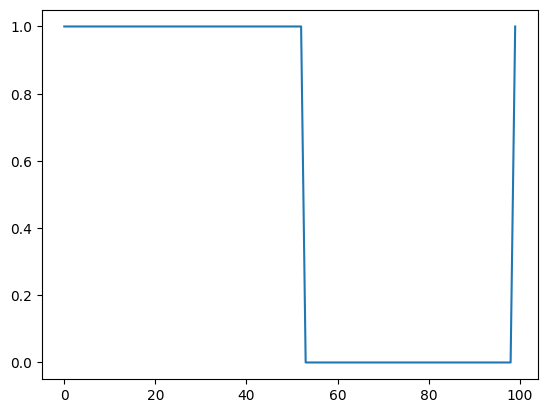

In [12]:
import matplotlib.pyplot as plt

# Analisi del risultato
plt.plot(x)

## Stabilità degli algoritmi di sostituzione

Gli algoritmi di sostituzione (in avanti o all'indietro) possono diventare instabili in certe situazioni. Si tratta di algoritmi intrinsecamente sequenziali, in cui la componente calcolata ad un passo del ciclo influisce sul calcolo di tutte le successive componenti.

Esempio:
$$
\begin{pmatrix}
l_{11} & 0\\
l_{21} &l_{22}
\end{pmatrix}\begin{pmatrix}x_1\\x_2\end{pmatrix} = \begin{pmatrix}b_1\\b_2\end{pmatrix}
$$
Indichiamo con $x^*=(x_1^*,x_2^*)^T$ la soluzione esatta e con $\tilde x=(\tilde x_1,\tilde x_2)^T$ la soluzione calcolata in aritmetica finita.
$$\tilde x_1 = fl(b_1/l_{11}) = \frac{b_1}{l_{11}}(1+\epsilon_1) = x_1^*(1+\epsilon_1) $$
dove $|\epsilon_1|\leq u$.


Per semplicità supponiamo che al secondo passo non vengano introdotti ulteriori errori:
$$\tilde x_2 = \frac{b_2-l_{21}\tilde x_1}{l_{22}}=\frac{b_2-l_{21} x_1^*(1+\epsilon_1)}{l_{22}} = {\frac{b_2-x_1^*}{l_{22}}} + \frac{l_{21}x_1^*}{l_{22}}\epsilon_1 = {x_2^*} + {\frac{l_{21}x_1^*}{l_{22}}}\epsilon_1  $$
L'errore $\epsilon_1$ commesso nel calcolo della prima componente viene amplificato nel calcolo della seconda da un fattore che può diventare grande quando $l_{21}>>l_{22}$.


## Metodo di fattorizzazione di Gauss

Se $A$ è non singolare e ha tutti i minori principali diversi da zero, esiste una matrice $L$ triangolare inferiore con diagonale unitaria e una matrice non singolare e triangolare superiore $U$ tali che

$$ A=LU $$

Pseudocodice con sovrascrittura della matrice $A$:

$$\begin{array}{l}
\text{for } k=1,n-1\\
\begin{array}{rl}
      &  \left\lfloor\begin{array}{l}
                       \text{for } i = k+1,n\\
                       \begin{array}{l}
                       \left\lfloor  \begin{array}{l} \quad a_{ik} \leftarrow a_{ik}/a_{kk};\\
											                            %\quad b_i \leftarrow b_i - b_k*a_{ik}\\
                                                  \text{for } j = k+1,n\\
                                                   \begin{array}{rl}
                                                   \lfloor & \quad a_{ij} \leftarrow a_{ij} - a_{ik}a_{kj}
                                                  \end{array}
                                   \end{array}\right.
																	\end{array}
                 \end{array}\right.
\end{array}
\end{array}$$

In [36]:
# Implementazione home-made del metodo di Gauss con 3 cicli annidati
def gauss_3loop(A):
    n, _ = A.shape  # Restituisce il numero di righe e di colonne
    for k in range(n-2):
        for i in range(k+1, n):  # Indice per accedere agli elementi
            A[i, k] = A[i, k] / A[k, k]
            for j in range(k+1, n-1):
                A[i, j] -= A[i, k] * A[k, j]
    return A

In [ ]:
# Implementazione home-made del metodo di Gauss con 2 cicli annidati
def gauss_2loop(A):
    n, _ = A.shape
    for k in range(n-2):
        for i in range(k+1, n):
            A[i, k] = A[i, k] / A[k, k]
            A[i,k+1:] -= A[i, k] * A[k, k+1:]
    return A

In [47]:
# Implementazione home-made del metodo di Gauss con 1 solo ciclo

def gauss_1loop(A):
    n, _ = A.shape
    for k in range(n-1):
        # Calcoliamo tutti i moltiplicatori
        A[k+1:,k] = A[k+1:,k] / A[k, k]
        
        # Aggiornamento
        A[k+1:,k+1:] = A[k+1:,k+1:] - np.reshape(A[k+1:,k], (n-k-1, 1)) @ np.reshape(A[k, k+1:], (1,n-k-1))
        # Servono vettori con seconda dimensione per effettuare le operazioni, quindi np.reshape.
        
    return A

In [48]:
n = 5

A = np.abs(np.random.randn(n, n)) + 2*np.eye(n)
A1 = A.copy()
A1 = gauss_1loop(A1.copy())

U = np.triu(A1)
L = np.tril(A1, -1) + np.eye(n)

print(A, U, L, sep='\n')
print('err =', np.linalg.norm(A - L@U))

[[2.27756579 0.94567131 0.44384584 0.03145813 0.01284118]
 [0.04039105 2.50033945 0.45735397 0.69784048 0.47955017]
 [2.23627683 0.74195595 2.51259369 0.80492378 0.01485524]
 [1.39442291 2.59675401 0.8610971  4.46015892 0.7981648 ]
 [1.87266036 0.74060557 0.77766749 0.15438843 2.7528077 ]]
[[2.27756579 0.94567131 0.44384584 0.03145813 0.01284118]
 [0.         2.48356862 0.44948267 0.69728259 0.47932244]
 [0.         0.         2.11056035 0.8264175  0.03825472]
 [0.         0.         0.         3.78661392 0.39681445]
 [0.         0.         0.         0.         2.74443219]]
[[ 1.          0.          0.          0.          0.        ]
 [ 0.01773431  1.          0.          0.          0.        ]
 [ 0.98187145 -0.07512243  1.          0.          0.        ]
 [ 0.61224265  0.81244935  0.10621532  1.          0.        ]
 [ 0.8222201  -0.01487552  0.19872202 -0.00668988  1.        ]]
err = 2.797157557069881e-17


In [16]:
#Valutazione dell'efficienza delle tre implementazioni
import timeit

